## Objetivo

O propósito desta análise é realizar uma análise estatística dos planos de telefonia Surf e Ultimate da empresa de telecomunicações Megaline para identificar qual deles gera maior receita para a empresa e como o comportamento de consumo dos usuários varia entre cada modalidade.

Para alcançar esse objetivo, as seguintes ações serão realizadas:

1. Tratamento de Dados: Limpeza da base de dados e arredondamento de valores de chamadas e internet conforme as regras de cobrança.

2. Análise Exploratória: Cálculo de médias, variâncias e criação de gráficos para comparar o consumo de minutos, mensagens e dados entre os planos.

3. Análise de Receita: Cálculo do faturamento mensal por usuário, considerando mensalidades e cobranças extras.

4. Teste de Hipóteses: Aplicação de testes estatísticos para validar se as diferenças de receita entre planos e regiões são significativas.

## Inicialização

In [378]:
# Carregando todas as bibliotecas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

## Carregue os dados

In [379]:
df_calls = pd.read_csv("megaline_calls.csv")
df_internet = pd.read_csv("megaline_internet.csv")
df_messages = pd.read_csv("megaline_messages.csv")
df_plans = pd.read_csv("megaline_plans.csv")
df_users = pd.read_csv("megaline_users.csv")

## Prepare os dados

## Planos

In [380]:
# Imprima informações gerais/resumo sobre o DataFrame dos planos
df_plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   messages_included      2 non-null      int64  
 1   mb_per_month_included  2 non-null      int64  
 2   minutes_included       2 non-null      int64  
 3   usd_monthly_pay        2 non-null      int64  
 4   usd_per_gb             2 non-null      int64  
 5   usd_per_message        2 non-null      float64
 6   usd_per_minute         2 non-null      float64
 7   plan_name              2 non-null      object 
dtypes: float64(2), int64(5), object(1)
memory usage: 256.0+ bytes


In [381]:

# Imprima uma amostra de dados dos planos
print('Número de valores duplicados:', df_plans.duplicated().sum())
df_plans

Número de valores duplicados: 0


,messages_included,mb_per_month_included,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute,plan_name
0,50,15360,500,20,10,0.03,0.03,surf
1,1000,30720,3000,70,7,0.01,0.01,ultimate



As colunas `usd_monthly_pay` e `usd_per_gb` estão com tipos de dados errado, sendo necessário alterá-las para tipo float

## Corrija os dados

Corrigindo a tipagem dos dados e os dados em Megabytes foram convertidos em Gigabytes na coluna `gb_per_month_included`.

In [382]:

def converse_datatime(df, date_columns):
    """
    Função utilizada para corrigir a tipagem das colunas cujo os dados são datas utilizando o pd.to_datatime
    """
    for col in date_columns:
        if col in df.columns:
            df[col] = pd.to_datetime(df[col])
    return df 
df_plans['gb_per_month_included'] = df_plans['mb_per_month_included'] / 1024
print(df_plans['gb_per_month_included'])
df_plans['usd_monthly_pay'] = df_plans['usd_monthly_pay'].astype(float)
df_plans['usd_per_gb'] = df_plans['usd_per_gb'].astype(float)
df_plans.info()

0    15.0
1    30.0
Name: gb_per_month_included, dtype: float64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   messages_included      2 non-null      int64  
 1   mb_per_month_included  2 non-null      int64  
 2   minutes_included       2 non-null      int64  
 3   usd_monthly_pay        2 non-null      float64
 4   usd_per_gb             2 non-null      float64
 5   usd_per_message        2 non-null      float64
 6   usd_per_minute         2 non-null      float64
 7   plan_name              2 non-null      object 
 8   gb_per_month_included  2 non-null      float64
dtypes: float64(5), int64(3), object(1)
memory usage: 272.0+ bytes


## Enriqueça os dados

Foram adiconados dados sobre a quantia de usuários ativos em cada plano assim comos os usuários inativos  também em novas colunas no DataFrame `df_plans`

In [383]:
df_plans

,messages_included,mb_per_month_included,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute,plan_name,gb_per_month_included
0,50,15360,500,20.0,10.0,0.03,0.03,surf,15.0
1,1000,30720,3000,70.0,7.0,0.01,0.01,ultimate,30.0


In [384]:
# contagem do numero de usuários ativo de cada plano do DataFrame df_users
active_surf = df_users.query('plan == "surf" and churn_date.isna()').shape[0]
churned_user_surf = df_users.query('plan == "surf" and ~churn_date.isna()').shape[0]
print('Plano surf:',active_surf)
print('Plano surf inativo:', churned_user_surf)
active_ultimate = df_users.query('plan == "ultimate" and churn_date.isna()').shape[0]
churned_user_ultimate = df_users.query('plan == "ultimate" and ~churn_date.isna()').shape[0]
print('Plano ultimate:', active_ultimate)
print('Plano ultimate inativo:', churned_user_ultimate)

Plano surf: 316
Plano surf inativo: 23
Plano ultimate: 150
Plano ultimate inativo: 11


In [385]:
df_plans['active_users'] = [active_surf, active_ultimate]
df_plans['churned_users'] = [churned_user_surf,churned_user_ultimate]

df_plans


,messages_included,mb_per_month_included,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute,plan_name,gb_per_month_included,active_users,churned_users
0,50,15360,500,20.0,10.0,0.03,0.03,surf,15.0,316,23
1,1000,30720,3000,70.0,7.0,0.01,0.01,ultimate,30.0,150,11


## Usuários

In [386]:
# Imprima informações gerais/resumo sobre o DataFrame dos usuários
df_users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     500 non-null    int64 
 1   first_name  500 non-null    object
 2   last_name   500 non-null    object
 3   age         500 non-null    int64 
 4   city        500 non-null    object
 5   reg_date    500 non-null    object
 6   plan        500 non-null    object
 7   churn_date  34 non-null     object
dtypes: int64(2), object(6)
memory usage: 31.4+ KB


In [387]:
# Imprima uma amostra de dados dos usuários
print('Número de valores duplicados:', df_users.duplicated().sum())
df_users.rename(columns={'plan':'plan_name'},inplace=True)
df_users.sample(5)


Número de valores duplicados: 0


,user_id,first_name,last_name,age,city,reg_date,plan_name,churn_date
414,1414,Georgianne,Herring,30,"Urban Honolulu, HI MSA",2018-03-03,surf,2018-09-01
435,1435,Darnell,Powell,23,"Washington-Arlington-Alexandria, DC-VA-MD-WV MSA",2018-07-24,ultimate,NaN
434,1434,Kai,Barr,18,"New York-Newark-Jersey City, NY-NJ-PA MSA",2018-03-06,surf,NaN
243,1243,Isaias,Compton,71,"Phoenix-Mesa-Chandler, AZ MSA",2018-05-11,surf,NaN
426,1426,Lamont,Conner,44,"San Francisco-Oakland-Berkeley, CA MSA",2018-07-09,ultimate,NaN


A tipagem dos dados de datas estão incorretos.

### Corrija os dados

Dados com as tipagens corrigidas

In [388]:
df_users.duplicated().sum()
print("-------------------------------------------------------")
df_users = converse_datatime(df_users, ['reg_date'])
df_users.info()
print("-------------------------------------------------------")
df_users = converse_datatime(df_users, ['churn_date'])
df_users.info()


-------------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   user_id     500 non-null    int64         
 1   first_name  500 non-null    object        
 2   last_name   500 non-null    object        
 3   age         500 non-null    int64         
 4   city        500 non-null    object        
 5   reg_date    500 non-null    datetime64[ns]
 6   plan_name   500 non-null    object        
 7   churn_date  34 non-null     object        
dtypes: datetime64[ns](1), int64(2), object(5)
memory usage: 31.4+ KB
-------------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   user_id     500 non-null    i

### Enriqueça os dados

Foram adicionados clunas  com o mês e ano de desativação do plano, status do plano do cliente e duração do plano do clinnte caso tenha desativado, caso contrário o valor é ausente 

In [389]:
df_users['plan_duration'] = df_users['churn_date'] - df_users['reg_date']
df_users['churn_mouth_year'] = df_users['churn_date'].dt.to_period('M')
df_users['status'] = df_users['churn_date'].isna().map({True: 'ativo', False: 'desativado'})
print(df_users.query('churn_date.notnull()').sample(5))

     user_id first_name last_name  age  \
180     1180      Wonda      Hays   24   
40      1040      Paris    Santos   72   
94      1094     Walter  Petersen   54   
296     1296     Weston    Conley   36   
67      1067       Robt     Allen   37   

                                                city   reg_date plan_name  \
180        New York-Newark-Jersey City, NY-NJ-PA MSA 2018-12-01      surf   
40   Philadelphia-Camden-Wilmington, PA-NJ-DE-MD MSA 2018-12-23      surf   
94            Los Angeles-Long Beach-Anaheim, CA MSA 2018-10-30      surf   
296    Miami-Fort Lauderdale-West Palm Beach, FL MSA 2018-10-20  ultimate   
67                     Grand Rapids-Kentwood, MI MSA 2018-09-24      surf   

    churn_date plan_duration churn_mouth_year      status  
180 2018-12-22       21 days          2018-12  desativado  
40  2018-12-30        7 days          2018-12  desativado  
94  2018-12-12       43 days          2018-12  desativado  
296 2018-12-18       59 days          2018-1

In [390]:
df_users

,user_id,first_name,last_name,age,city,reg_date,plan_name,churn_date,plan_duration,churn_mouth_year,status
0,1000,Anamaria,Bauer,45,"Atlanta-Sandy Springs-Roswell, GA MSA",2018-12-24,ultimate,NaT,NaT,NaT,ativo
1,1001,Mickey,Wilkerson,28,"Seattle-Tacoma-Bellevue, WA MSA",2018-08-13,surf,NaT,NaT,NaT,ativo
2,1002,Carlee,Hoffman,36,"Las Vegas-Henderson-Paradise, NV MSA",2018-10-21,surf,NaT,NaT,NaT,ativo
3,1003,Reynaldo,Jenkins,52,"Tulsa, OK MSA",2018-01-28,surf,NaT,NaT,NaT,ativo
4,1004,Leonila,Thompson,40,"Seattle-Tacoma-Bellevue, WA MSA",2018-05-23,surf,NaT,NaT,NaT,ativo
...,...,...,...,...,...,...,...,...,...,...,...
495,1495,Fidel,Sharpe,67,"New York-Newark-Jersey City, NY-NJ-PA MSA",2018-09-04,surf,NaT,NaT,NaT,ativo
496,1496,Ariel,Shepherd,49,"New Orleans-Metairie, LA MSA",2018-02-20,surf,NaT,NaT,NaT,ativo
497,1497,Donte,Barrera,49,"Los Angeles-Long Beach-Anaheim, CA MSA",2018-12-10,ultimate,NaT,NaT,NaT,ativo
498,1498,Scot,Williamson,51,"New York-Newark-Jersey City, NY-NJ-PA MSA",2018-02-04,surf,NaT,NaT,NaT,ativo


## Chamadas

In [391]:
# Imprima informações gerais/resumo sobre o DataFrame das chamadas
df_calls.info()
print("Número de duplicatas:", df_calls.duplicated().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 137735 entries, 0 to 137734
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   id         137735 non-null  object 
 1   user_id    137735 non-null  int64  
 2   call_date  137735 non-null  object 
 3   duration   137735 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 4.2+ MB
Número de duplicatas: 0


In [392]:
# Imprima uma amostra de dados das chamadas
df_calls.sample(5)


,id,user_id,call_date,duration
26461,1100_18,1100,2018-09-19,15.59
41429,1153_57,1153,2018-08-14,17.32
68273,1246_292,1246,2018-07-24,18.40
108836,1384_173,1384,2018-11-27,0.00
92586,1333_128,1333,2018-12-01,10.72


O tipo de dado para a coluna `call_date` está incorreta e é necessário corrigir a duração das chamas pois há arredondamento.

### Corrija os dados

A tipagem dos dados foram corrigidos para a tipagem correta.



In [393]:
df_calls = converse_datatime(df_calls,['call_date'])
df_calls.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 137735 entries, 0 to 137734
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   id         137735 non-null  object        
 1   user_id    137735 non-null  int64         
 2   call_date  137735 non-null  datetime64[ns]
 3   duration   137735 non-null  float64       
dtypes: datetime64[ns](1), float64(1), int64(1), object(1)
memory usage: 4.2+ MB


### Enriqueça os dados

A duração das chamdas foram arredondados para cima como instruido na descrição.
Foi criada uma nova coluna chamada `duration_rounded` para mostrar os valores arredondados para cima e para preservar os dados originais. Foi criado, também, um dataframe chamado `calls_duration_per_month_user` que mostra a quantidade de minutos utilizados por mês por cada usuário.


In [394]:
df_calls.sample(5)

,id,user_id,call_date,duration
10600,1046_466,1046,2018-07-13,6.11
42661,1156_266,1156,2018-04-24,0.80
119966,1417_744,1417,2018-11-17,10.79
126143,1447_8,1447,2018-12-17,14.20
58786,1212_296,1212,2018-12-15,7.80


In [395]:
df_calls['calls_duration_rounded'] = np.ceil(df_calls['duration'])
df_calls.sample(5)

,id,user_id,call_date,duration,calls_duration_rounded
103076,1365_272,1365,2018-12-20,8.83,9.0
132720,1478_174,1478,2018-10-01,0.88,1.0
78999,1282_489,1282,2018-11-22,3.93,4.0
55332,1198_76,1198,2018-09-08,20.55,21.0
48914,1176_13,1176,2018-10-22,15.09,16.0


In [396]:
df_calls['month_year'] = df_calls['call_date'].dt.to_period('M')
calls_duration_per_month_user = df_calls.groupby(['user_id', 'month_year'])['calls_duration_rounded'].sum().reset_index()
print(calls_duration_per_month_user)

      user_id month_year  calls_duration_rounded
0        1000    2018-12                   124.0
1        1001    2018-08                   182.0
2        1001    2018-09                   315.0
3        1001    2018-10                   393.0
4        1001    2018-11                   426.0
...       ...        ...                     ...
2253     1498    2018-12                   339.0
2254     1499    2018-09                   346.0
2255     1499    2018-10                   385.0
2256     1499    2018-11                   308.0
2257     1499    2018-12                   496.0

[2258 rows x 3 columns]


In [397]:
print(df_calls.isnull().sum())


id                        0
user_id                   0
call_date                 0
duration                  0
calls_duration_rounded    0
month_year                0
dtype: int64


## Mensagens

In [398]:
# Imprima informações gerais/resumo sobre o DataFrame das mensagens
df_messages.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76051 entries, 0 to 76050
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   id            76051 non-null  object
 1   user_id       76051 non-null  int64 
 2   message_date  76051 non-null  object
dtypes: int64(1), object(2)
memory usage: 1.7+ MB


In [399]:
# Imprima uma amostra dos dados das mensagens
print('Número de duplicatas:', df_messages.duplicated().sum())
df_messages.sample(5)


Número de duplicatas: 0


,id,user_id,message_date
63850,1407_72,1407,2018-12-05
33745,1212_228,1212,2018-08-15
40775,1261_441,1261,2018-05-06
75748,1492_94,1492,2018-12-06
30135,1188_153,1188,2018-10-07


A tipagem dos dados de data estão incorretos, valores ausentes e duplicatas não foram encontrados.

### Corrija os dados

Corrigindo timagem dos dados


In [400]:
df_messages = converse_datatime(df_messages,['message_date'])
df_messages.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76051 entries, 0 to 76050
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   id            76051 non-null  object        
 1   user_id       76051 non-null  int64         
 2   message_date  76051 non-null  datetime64[ns]
dtypes: datetime64[ns](1), int64(1), object(1)
memory usage: 1.7+ MB


### Enriqueça os dados

Foi criado o DataFrame `message_per_user_month` contando o número de mensagens por mês por cada usuário.

In [401]:
df_messages['month_year'] = df_messages['message_date'].dt.to_period('M')
message_per_user_month = df_messages.groupby(['user_id', 'month_year']).size().reset_index(name='messages_count')
print(message_per_user_month)

      user_id month_year  messages_count
0        1000    2018-12              11
1        1001    2018-08              30
2        1001    2018-09              44
3        1001    2018-10              53
4        1001    2018-11              36
...       ...        ...             ...
1801     1496    2018-09              21
1802     1496    2018-10              18
1803     1496    2018-11              13
1804     1496    2018-12              11
1805     1497    2018-12              50

[1806 rows x 3 columns]


In [402]:
print(df_messages.isnull().sum())
df_messages.info()

id              0
user_id         0
message_date    0
month_year      0
dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76051 entries, 0 to 76050
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   id            76051 non-null  object        
 1   user_id       76051 non-null  int64         
 2   message_date  76051 non-null  datetime64[ns]
 3   month_year    76051 non-null  period[M]     
dtypes: datetime64[ns](1), int64(1), object(1), period[M](1)
memory usage: 2.3+ MB


## Internet

In [403]:
# Imprima informações gerais/resumo sobre o DataFrame da internet
df_internet.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104825 entries, 0 to 104824
Data columns (total 4 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            104825 non-null  object 
 1   user_id       104825 non-null  int64  
 2   session_date  104825 non-null  object 
 3   mb_used       104825 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 3.2+ MB


In [404]:
#  Imprima uma amostra de dados para o tráfego da internet
print('Número de duplicatas:', df_internet.duplicated().sum())
df_internet.sample(5)

Número de duplicatas: 0


,id,user_id,session_date,mb_used
100027,1474_196,1474,2018-12-25,9.36
10167,1053_3,1053,2018-11-18,525.28
4933,1028_506,1028,2018-03-03,606.75
56477,1255_194,1255,2018-10-13,385.31
73165,1343_20,1343,2018-11-05,475.65


O tipo de dado para a coluna `session_date` está incorreta e a empresa mede os dados em Gigabytes.

### Corrija os dados


corrigindo de megabytes para gigabytes

In [444]:
df_internet = converse_datatime(df_internet,['session_date'])
df_internet.info()
print("-------------------------------------------------------")
df_internet['gb_used'] = df_internet['mb_used'] / 1024
df_internet.head(5)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104825 entries, 0 to 104824
Data columns (total 6 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   id            104825 non-null  object        
 1   user_id       104825 non-null  int64         
 2   session_date  104825 non-null  datetime64[ns]
 3   mb_used       104825 non-null  float64       
 4   gb_used       104825 non-null  float64       
 5   month_year    104825 non-null  period[M]     
dtypes: datetime64[ns](1), float64(2), int64(1), object(1), period[M](1)
memory usage: 4.8+ MB
-------------------------------------------------------


,id,user_id,session_date,mb_used,gb_used,month_year
0,1000_13,1000,2018-12-29,89.86,0.087754,2018-12
1,1000_204,1000,2018-12-31,0.00,0.000000,2018-12
2,1000_379,1000,2018-12-28,660.40,0.644922,2018-12
3,1000_413,1000,2018-12-26,270.99,0.264639,2018-12
4,1000_442,1000,2018-12-27,880.22,0.859590,2018-12


In [406]:
df_internet[df_internet['user_id']==1482]

,id,user_id,session_date,mb_used,gb_used
101156,1482_0,1482,2018-11-13,613.12,0.598750
101157,1482_1,1482,2018-11-26,782.18,0.763848
101158,1482_2,1482,2018-11-19,337.87,0.329951
101159,1482_3,1482,2018-11-26,611.59,0.597256
101160,1482_4,1482,2018-11-21,103.00,0.100586
...,...,...,...,...,...
101221,1482_65,1482,2018-11-29,96.64,0.094375
101222,1482_66,1482,2018-11-12,423.02,0.413105
101223,1482_67,1482,2018-11-06,15.58,0.015215
101224,1482_68,1482,2018-11-09,16.15,0.015771


### Enriqueça os dados

Foi criado um dataframe com dados informando a quantidade de gigabytes utilizados por mês por cada usuário.

In [407]:
df_internet['month_year'] = df_internet['session_date'].dt.to_period('M')
giga_month_per_user = df_internet.groupby(['user_id','month_year'])['gb_used'].sum().reset_index()
print(giga_month_per_user.head(5))

   user_id month_year    gb_used
0     1000    2018-12   1.856904
1     1001    2018-08   6.756982
2     1001    2018-09  13.002754
3     1001    2018-10  21.807119
4     1001    2018-11  18.070605


In [408]:
print(df_internet.isnull().sum())

id              0
user_id         0
session_date    0
mb_used         0
gb_used         0
month_year      0
dtype: int64


## Estude as condições dos planos

Dados dos planos oferecidos pela empresa.

In [409]:
# Imprima as condições dos planos e certifique-se de que elas fazem sentido para você
df_plans

,messages_included,mb_per_month_included,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute,plan_name,gb_per_month_included,active_users,churned_users
0,50,15360,500,20.0,10.0,0.03,0.03,surf,15.0,316,23
1,1000,30720,3000,70.0,7.0,0.01,0.01,ultimate,30.0,150,11


## Agregue os dados por usuário

Agregando por ususário e mês/ano

In [410]:
# Calcule o número de chamadas feitas por cada usuário por mês. Salve o resultado.
total_calls_per_user = df_calls.groupby(['user_id','month_year']).size()
print(total_calls_per_user)
print("-------------------------------------------------------")
print(calls_duration_per_month_user) # df que mostra o total de minutos em chamadas gastos por mês por cada usuário

user_id  month_year
1000     2018-12       16
1001     2018-08       27
         2018-09       49
         2018-10       65
         2018-11       64
                       ..
1498     2018-12       39
1499     2018-09       41
         2018-10       53
         2018-11       45
         2018-12       65
Length: 2258, dtype: int64
-------------------------------------------------------
      user_id month_year  calls_duration_rounded
0        1000    2018-12                   124.0
1        1001    2018-08                   182.0
2        1001    2018-09                   315.0
3        1001    2018-10                   393.0
4        1001    2018-11                   426.0
...       ...        ...                     ...
2253     1498    2018-12                   339.0
2254     1499    2018-09                   346.0
2255     1499    2018-10                   385.0
2256     1499    2018-11                   308.0
2257     1499    2018-12                   496.0

[2258 rows x 3 columns

In [411]:
# Calcule a quantidade de minutos gastos por cada usuário por mês. Salve o resultado.
"""
Já feito anteriormente
"""


'\nJá feito anteriormente\n'

In [412]:
# Calcule o número de mensagens enviadas por cada usuário por mês. Salve o resultado.
print(message_per_user_month)

      user_id month_year  messages_count
0        1000    2018-12              11
1        1001    2018-08              30
2        1001    2018-09              44
3        1001    2018-10              53
4        1001    2018-11              36
...       ...        ...             ...
1801     1496    2018-09              21
1802     1496    2018-10              18
1803     1496    2018-11              13
1804     1496    2018-12              11
1805     1497    2018-12              50

[1806 rows x 3 columns]


In [413]:
# Calcule o volume de tráfego de internet usado por cada usuário por mês. Salve o resultado.
print(giga_month_per_user)

      user_id month_year    gb_used
0        1000    2018-12   1.856904
1        1001    2018-08   6.756982
2        1001    2018-09  13.002754
3        1001    2018-10  21.807119
4        1001    2018-11  18.070605
...       ...        ...        ...
2272     1498    2018-12  22.595400
2273     1499    2018-09  12.680430
2274     1499    2018-10  19.035576
2275     1499    2018-11  16.419756
2276     1499    2018-12  21.542197

[2277 rows x 3 columns]


In [415]:
# Junte os dados de chamadas, minutos, mensagens e internet com base em user_id e month

# df_consolidado = df1.merge(df2, on=['user_id', 'month'], how='outer') para ajudar a lembrar

df_users_plans = calls_duration_per_month_user.merge(message_per_user_month, on=['user_id', 'month_year'], how='outer')
df_users_plans = df_users_plans.merge(giga_month_per_user, on=['user_id','month_year'], how='outer')
df_users_plans = df_users_plans.merge(df_users, on=['user_id'], how='right')
df_users_plans[df_users_plans['user_id']==1482]
df_users_plans [['calls_duration_rounded','messages_count','gb_used']] = df_users_plans [['calls_duration_rounded','messages_count','gb_used']].fillna(0)




df_users_plans.columns

Index(['user_id', 'month_year', 'calls_duration_rounded', 'messages_count',
       'gb_used', 'first_name', 'last_name', 'age', 'city', 'reg_date',
       'plan_name', 'churn_date', 'plan_duration', 'churn_mouth_year',
       'status'],
      dtype='object')

In [416]:
df_plans.columns

Index(['messages_included', 'mb_per_month_included', 'minutes_included',
       'usd_monthly_pay', 'usd_per_gb', 'usd_per_message', 'usd_per_minute',
       'plan_name', 'gb_per_month_included', 'active_users', 'churned_users'],
      dtype='object')

Adicionando informações dos planos

In [418]:

df_users_plans_total = df_users_plans.merge(df_plans, on=['plan_name'], how='right')
df_users_plans_total.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 2303 entries, 0 to 2302
Data columns (total 25 columns):
 #   Column                  Non-Null Count  Dtype          
---  ------                  --------------  -----          
 0   user_id                 2303 non-null   int64          
 1   month_year              2293 non-null   period[M]      
 2   calls_duration_rounded  2303 non-null   float64        
 3   messages_count          2303 non-null   float64        
 4   gb_used                 2303 non-null   float64        
 5   first_name              2303 non-null   object         
 6   last_name               2303 non-null   object         
 7   age                     2303 non-null   int64          
 8   city                    2303 non-null   object         
 9   reg_date                2303 non-null   datetime64[ns] 
 10  plan_name               2303 non-null   object         
 11  churn_date              160 non-null    datetime64[ns] 
 12  plan_duration           160 non-nu

Calculando receita mensal e valores extras de cada plano

In [419]:
# Calcule a receita mensal para cada usuário

# calculando valores extras
df_users_plans_total['extra_calls_minutes'] = (df_users_plans_total['calls_duration_rounded'] - df_users_plans_total['minutes_included']).clip(lower=0)
df_users_plans_total['extra_messages'] = (df_users_plans_total['messages_count'] - df_users_plans_total['messages_included']).clip(lower=0)
df_users_plans_total['extra_gb'] = (df_users_plans_total['gb_used'] - df_users_plans_total['gb_per_month_included']).clip(lower=0)
df_users_plans_total[['extra_calls_minutes','extra_messages','extra_gb']].sample(5)

,extra_calls_minutes,extra_messages,extra_gb
2232,0.0,0.0,0.000000
440,7.0,0.0,5.775381
760,0.0,0.0,3.328193
1612,0.0,0.0,0.000000
2007,0.0,0.0,0.000000


In [420]:
# calulando receita 
df_users_plans_total['total_revenue'] = (
    df_users_plans_total['usd_monthly_pay'] + (
        (df_users_plans_total['extra_calls_minutes'] * df_users_plans_total['usd_per_minute']) +
        (df_users_plans_total['extra_messages'] * df_users_plans_total['usd_per_message']) +
        (df_users_plans_total['extra_gb'] * df_users_plans_total['usd_per_gb'])
        )
    )

pd.set_option('display.max_columns', None)
df_users_plans_total

,user_id,month_year,calls_duration_rounded,messages_count,gb_used,first_name,last_name,age,city,reg_date,plan_name,churn_date,plan_duration,churn_mouth_year,status,messages_included,mb_per_month_included,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute,gb_per_month_included,active_users,churned_users,extra_calls_minutes,extra_messages,extra_gb,total_revenue
0,1001,2018-08,182.0,30.0,6.756982,Mickey,Wilkerson,28,"Seattle-Tacoma-Bellevue, WA MSA",2018-08-13,surf,NaT,NaT,NaT,ativo,50,15360,500,20.0,10.0,0.03,0.03,15.0,316,23,0.0,0.0,0.000000,20.000000
1,1001,2018-09,315.0,44.0,13.002754,Mickey,Wilkerson,28,"Seattle-Tacoma-Bellevue, WA MSA",2018-08-13,surf,NaT,NaT,NaT,ativo,50,15360,500,20.0,10.0,0.03,0.03,15.0,316,23,0.0,0.0,0.000000,20.000000
2,1001,2018-10,393.0,53.0,21.807119,Mickey,Wilkerson,28,"Seattle-Tacoma-Bellevue, WA MSA",2018-08-13,surf,NaT,NaT,NaT,ativo,50,15360,500,20.0,10.0,0.03,0.03,15.0,316,23,0.0,3.0,6.807119,88.161191
3,1001,2018-11,426.0,36.0,18.070605,Mickey,Wilkerson,28,"Seattle-Tacoma-Bellevue, WA MSA",2018-08-13,surf,NaT,NaT,NaT,ativo,50,15360,500,20.0,10.0,0.03,0.03,15.0,316,23,0.0,0.0,3.070605,50.706055
4,1001,2018-12,412.0,44.0,18.915215,Mickey,Wilkerson,28,"Seattle-Tacoma-Bellevue, WA MSA",2018-08-13,surf,NaT,NaT,NaT,ativo,50,15360,500,20.0,10.0,0.03,0.03,15.0,316,23,0.0,0.0,3.915215,59.152148
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2298,1493,2018-09,529.0,0.0,14.639814,Cicely,Wynn,18,"Boston-Cambridge-Newton, MA-NH MSA",2018-03-06,ultimate,NaT,NaT,NaT,ativo,1000,30720,3000,70.0,7.0,0.01,0.01,30.0,150,11,0.0,0.0,0.000000,70.000000
2299,1493,2018-10,450.0,0.0,15.946846,Cicely,Wynn,18,"Boston-Cambridge-Newton, MA-NH MSA",2018-03-06,ultimate,NaT,NaT,NaT,ativo,1000,30720,3000,70.0,7.0,0.01,0.01,30.0,150,11,0.0,0.0,0.000000,70.000000
2300,1493,2018-11,500.0,0.0,15.264434,Cicely,Wynn,18,"Boston-Cambridge-Newton, MA-NH MSA",2018-03-06,ultimate,NaT,NaT,NaT,ativo,1000,30720,3000,70.0,7.0,0.01,0.01,30.0,150,11,0.0,0.0,0.000000,70.000000
2301,1493,2018-12,473.0,0.0,14.930752,Cicely,Wynn,18,"Boston-Cambridge-Newton, MA-NH MSA",2018-03-06,ultimate,NaT,NaT,NaT,ativo,1000,30720,3000,70.0,7.0,0.01,0.01,30.0,150,11,0.0,0.0,0.000000,70.000000


## Estude o comportamento do usuário

Calculando estatística descritivas sobre as chamdas e os usuários de cada plano para o estudo do comportamento dos usuários

### Chamadas

In [421]:

# Compare a duração média das chamadas de cada plano para cada mês. Crie um gráfico de barras para visualizar o resultado.

print("-------------------------------------------------------")
print('Média de minutos e minutos extras do plano Surf:')
print("-------------------------------------------------------")
surf_calls_mean = df_users_plans_total[df_users_plans_total['plan_name'] == 'surf']
surf_calls_duration_mean =  surf_calls_mean['calls_duration_rounded']
surf_calls_duration_mean = surf_calls_duration_mean.mean()
surf_calls_duration_mean

-------------------------------------------------------
Média de minutos e minutos extras do plano Surf:
-------------------------------------------------------


427.12032932235593

In [422]:
surf_calls_extra_mean =  surf_calls_mean['extra_calls_minutes']
surf_calls_extra_mean = surf_calls_extra_mean.mean()
surf_calls_extra_mean

61.22545915136162

In [423]:
print("-------------------------------------------------------")
print('Média de minutos e minutos extras do plano Ultimate:')
print("-------------------------------------------------------")
ultimate_calls_mean = df_users_plans_total[df_users_plans_total['plan_name'] == 'ultimate']
ultimate_calls_duration_mean =  ultimate_calls_mean['calls_duration_rounded']
ultimate_calls_duration_mean = ultimate_calls_duration_mean.mean()
ultimate_calls_duration_mean

-------------------------------------------------------
Média de minutos e minutos extras do plano Ultimate:
-------------------------------------------------------


428.0718232044199

In [424]:
ultimate_calls_extra_mean =  ultimate_calls_mean['extra_calls_minutes']
ultimate_calls_extra_mean = ultimate_calls_extra_mean.mean()
ultimate_calls_extra_mean

0.0

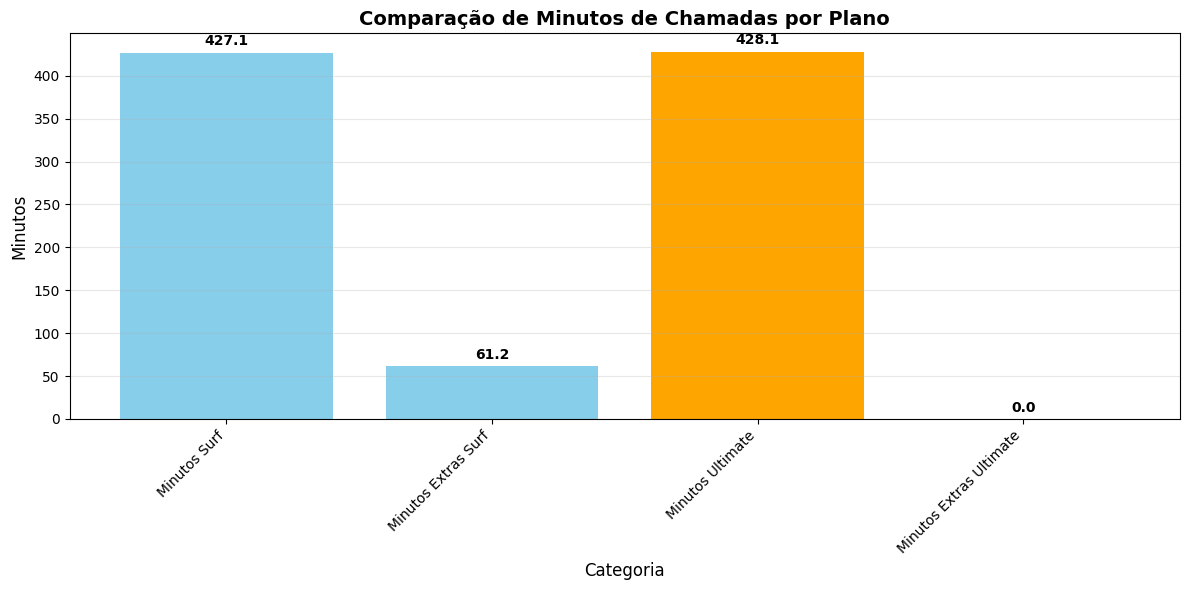

In [425]:
categorias = [
    'Minutos Surf',
    'Minutos Extras Surf', 
    'Minutos Ultimate',
    'Minutos Extras Ultimate'
]

valores = [
    surf_calls_duration_mean,      
    surf_calls_extra_mean,         
    ultimate_calls_duration_mean,  
    ultimate_calls_extra_mean      
]


plt.figure(figsize=(12, 6))
bars = plt.bar(categorias, valores, color=['skyblue', 'skyblue', 'orange', 'orange'])


for bar, valor in zip(bars, valores):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5, 
             f'{valor:.1f}', ha='center', va='bottom', fontweight='bold')

plt.title('Comparação de Minutos de Chamadas por Plano', fontsize=14, fontweight='bold')
plt.ylabel('Minutos', fontsize=12)
plt.xlabel('Categoria', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

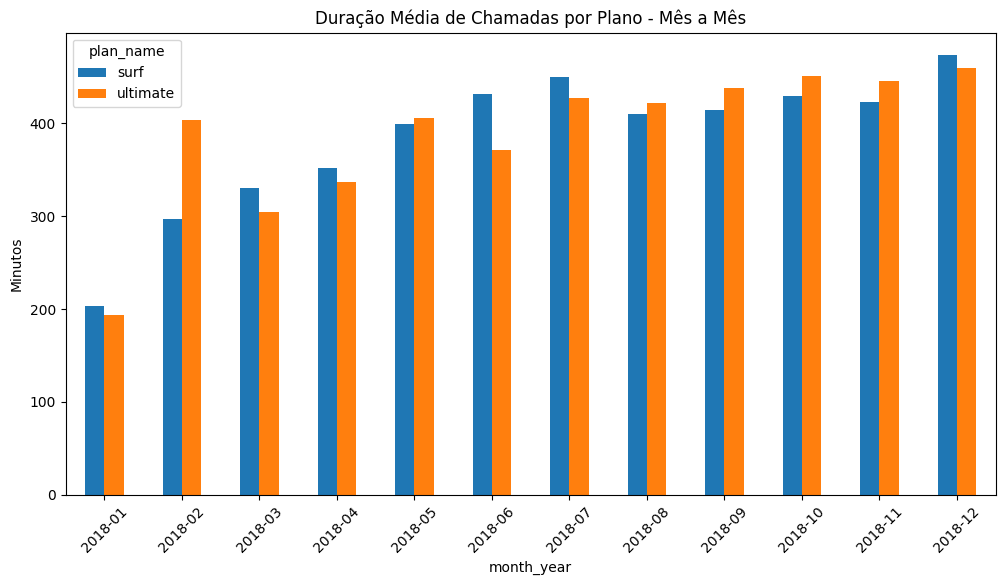

In [426]:


monthly_avg = df_users_plans_total.groupby(['plan_name', 'month_year'])['calls_duration_rounded'].mean().reset_index()
monthly_avg_pivot = monthly_avg.pivot(index='month_year', columns='plan_name', values='calls_duration_rounded')
monthly_avg_pivot.plot(kind='bar', figsize=(12, 6),title='Duração Média de Chamadas por Plano - Mês a Mês')
plt.ylabel('Minutos')
plt.xticks(rotation=45)
plt.show()



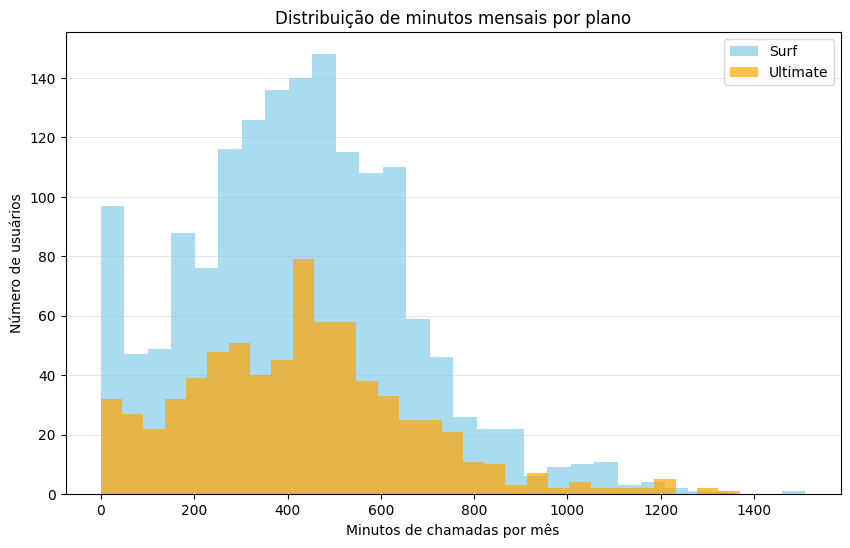

In [427]:
# Compare o número de minutos que os usuários de cada plano necessitam a cada mês. Construa um histograma.


surf_minutes = df_users_plans_total[df_users_plans_total['plan_name'] == 'surf']['calls_duration_rounded']
ultimate_minutes = df_users_plans_total[df_users_plans_total['plan_name'] == 'ultimate']['calls_duration_rounded']


plt.figure(figsize=(10, 6))
plt.hist(surf_minutes, bins=30, alpha=0.7, label='Surf', color='skyblue')
plt.hist(ultimate_minutes, bins=30, alpha=0.7, label='Ultimate', color='orange')


plt.title('Distribuição de minutos mensais por plano')
plt.xlabel('Minutos de chamadas por mês')
plt.ylabel('Número de usuários')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()


Calculando a média e a variância da duração das chamadas para verificar se os usuários dos planos ultimate e surf possuem comportamenteos diferentes

In [428]:
# Calcule a média e a variância da duração mensal das chamadas

surf_stats = df_users_plans_total[df_users_plans_total['plan_name'] == 'surf']['calls_duration_rounded'].agg(['mean','var'])
ultimate_stats = df_users_plans_total[df_users_plans_total['plan_name'] == 'ultimate']['calls_duration_rounded'].agg(['mean','var'])

print("Surf")
print(f"Média: {surf_stats['mean']:.2f} minutos")
print(f"Variância: {surf_stats['var']:.2f}")

print("\nUltimate")
print(f"Média: {ultimate_stats['mean']:.2f} minutos")
print(f"Variância: {ultimate_stats['var']:.2f}")

Surf
Média: 427.12 minutos
Variância: 55455.58

Ultimate
Média: 428.07 minutos
Variância: 58543.88


<Figure size 800x600 with 0 Axes>

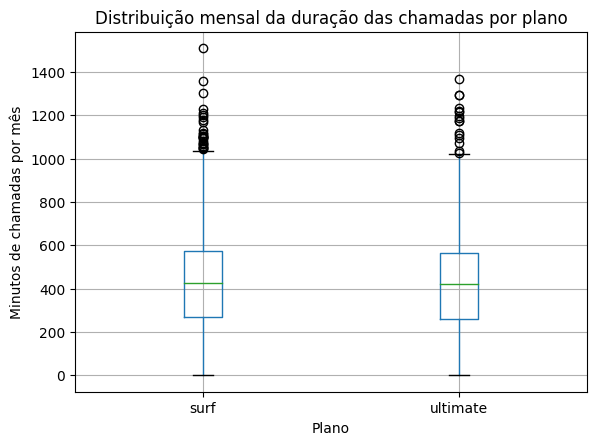

In [429]:
# Faça um diagrama de caixa para visualizar a distribuição da duração mensal das chamadas

plt.figure(figsize=(8,6))

df_users_plans_total.boxplot(
    column='calls_duration_rounded',
    by='plan_name'
)

plt.title('Distribuição mensal da duração das chamadas por plano')
plt.suptitle('')
plt.xlabel('Plano')
plt.ylabel('Minutos de chamadas por mês')

plt.show()

Após analises dos gráficos, podemos conclui que, embora os planos tenham grande diferença entre seus pacotes, o comportamento dos usuários não se diferencia tanto. Há uma forte similaridade nas necessidades em relação a quantidade de minutos utilizados ao longo do ano.

### Mensagens

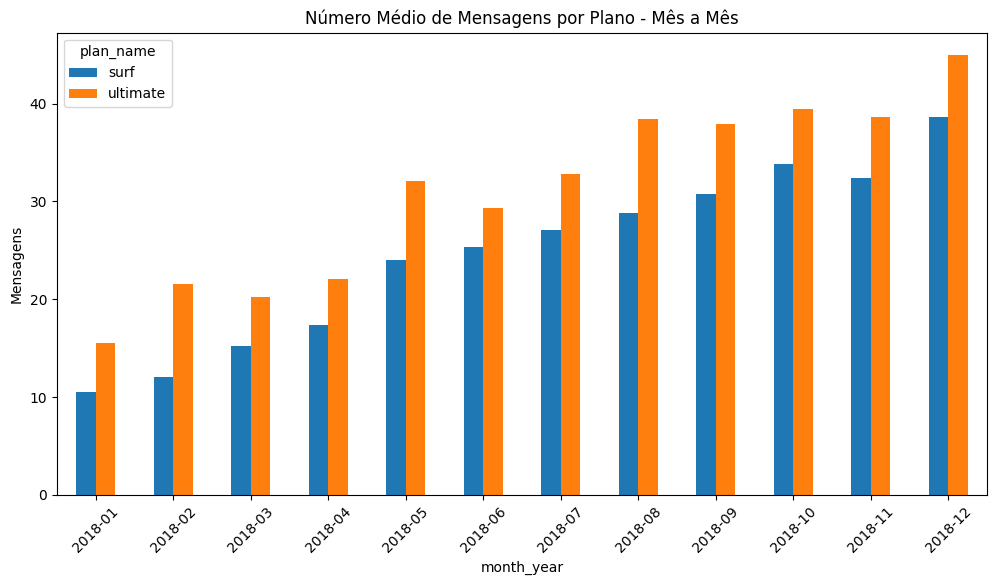

In [430]:
# Compare o número de mensagens que os usuários de cada plano costumam enviar a cada mês
monthly_avg = df_users_plans_total.groupby(['plan_name', 'month_year'])['messages_count'].mean().reset_index()
monthly_avg_pivot = monthly_avg.pivot(index='month_year', columns='plan_name', values='messages_count')
monthly_avg_pivot.plot(kind='bar', figsize=(12, 6),title='Número Médio de Mensagens por Plano - Mês a Mês')
plt.ylabel('Mensagens')
plt.xticks(rotation=45)
plt.show()

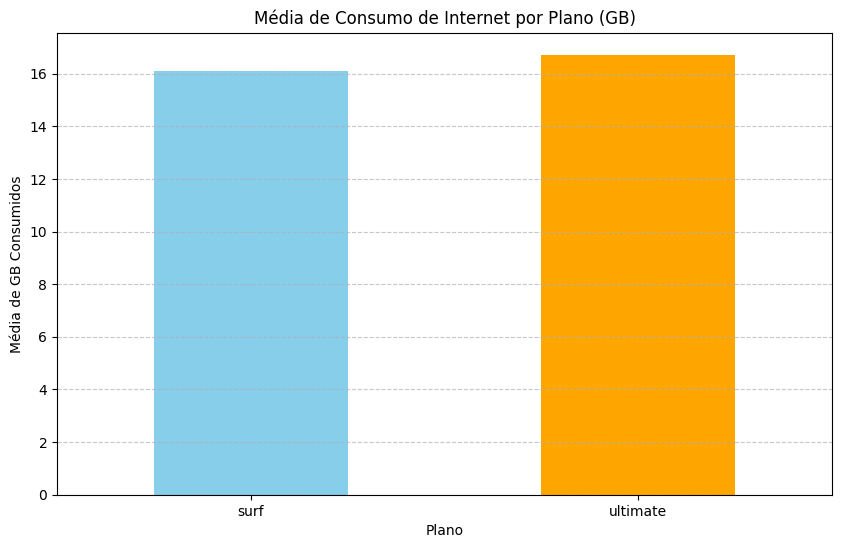

In [431]:
# Compare a quantidade de tráfego de internet consumido pelos usuários por plano


df_internet_plan = df_users_plans_total.groupby('plan_name')['gb_used'].mean()
plt.figure(figsize=(10, 6))
df_internet_plan.plot(kind='bar', color=['skyblue', 'orange'])
plt.title('Média de Consumo de Internet por Plano (GB)')
plt.xlabel('Plano')
plt.ylabel('Média de GB Consumidos')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Podemos constatar que em media os usuários utilizam valores aproximados de pacotes de internet independente do plano, porém, o plano Ultimate contém um tráfego ligeiramente maior em comparação com o plano surf.

### Internet

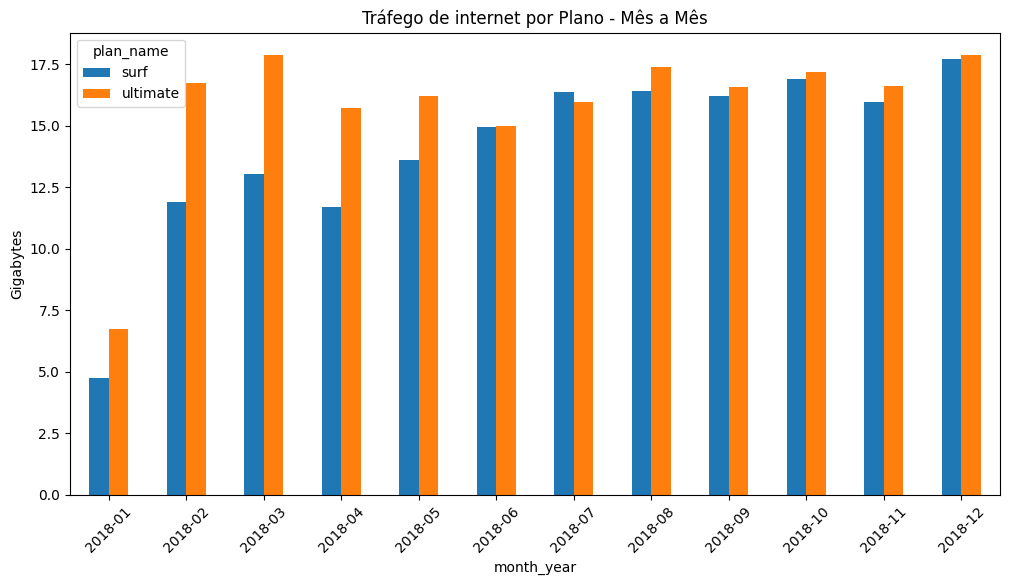

In [432]:
monthly_avg = df_users_plans_total.groupby(['plan_name', 'month_year'])['gb_used'].mean().reset_index()
monthly_avg_pivot = monthly_avg.pivot(index='month_year', columns='plan_name', values='gb_used')
monthly_avg_pivot.plot(kind='bar', figsize=(12, 6),title='Tráfego de internet por Plano - Mês a Mês')
plt.ylabel('Gigabytes')
plt.xticks(rotation=45)
plt.show()


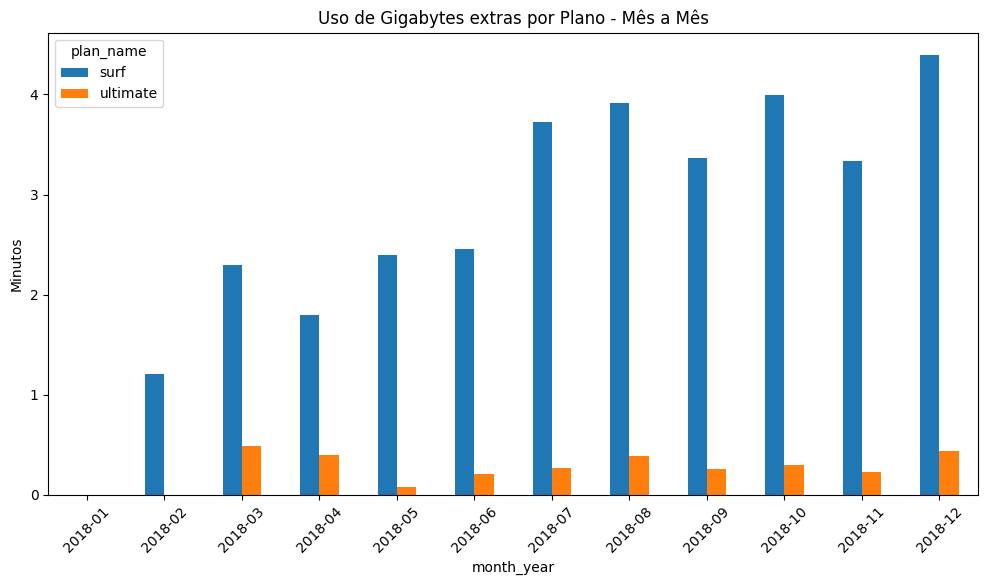

In [433]:
monthly_avg = df_users_plans_total.groupby(['plan_name', 'month_year'])['extra_gb'].mean().reset_index()
monthly_avg_pivot = monthly_avg.pivot(index='month_year', columns='plan_name', values='extra_gb')
monthly_avg_pivot.plot(kind='bar', figsize=(12, 6),title='Uso de Gigabytes extras por Plano - Mês a Mês')
plt.ylabel('Minutos')
plt.xticks(rotation=45)
plt.show()

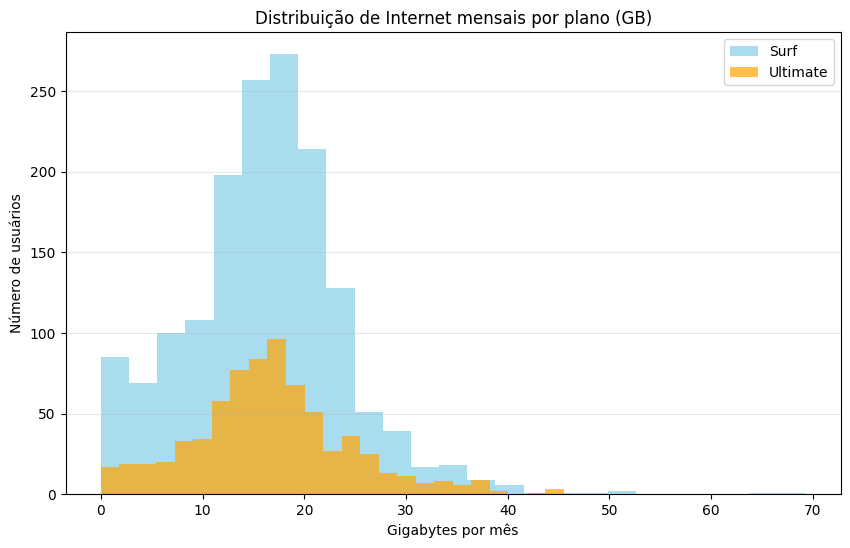

In [434]:
surf_minutes = df_users_plans_total[df_users_plans_total['plan_name'] == 'surf']['gb_used']
ultimate_minutes = df_users_plans_total[df_users_plans_total['plan_name'] == 'ultimate']['gb_used']


plt.figure(figsize=(10, 6))
plt.hist(surf_minutes, bins=25, alpha=0.7, label='Surf', color='skyblue')
plt.hist(ultimate_minutes, bins=25, alpha=0.7, label='Ultimate', color='orange')


plt.title('Distribuição de Internet mensais por plano (GB)')
plt.xlabel('Gigabytes por mês')
plt.ylabel('Número de usuários')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

Diferente das chamadas, o tráfego de internet mostra que os usuários do plano Surf frequentemente excedem suas franquias, gerando um uso constante de pacotes extras. Embora o consumo médio seja similar entre os planos, os usuários do Ultimate possuem um comportamento mais estável dentro dos limites contratados, enquanto os usuários do Surf demonstram uma necessidade de dados superior ao que o plano básico oferece.

## Receita

Descrevendo estatisticamente a receita dos planos

In [435]:
surf_revenue = df_users_plans_total[df_users_plans_total['plan_name'] == 'surf']['total_revenue']
ultimate_revenue = df_users_plans_total[df_users_plans_total['plan_name'] == 'ultimate']['total_revenue']


print('Plano Surf')
print(f"Média: ${surf_revenue.mean():.2f}")
print(f"Mediana: ${surf_revenue.median():.2f}")
print(f"Variância: {surf_revenue.var():.2f}")
print(f"Desvio Padrão: ${surf_revenue.std():.2f}")

print('\nPlano Ultimate')
print(f"Média: ${ultimate_revenue.mean():.2f}")
print(f"Mediana: ${ultimate_revenue.median():.2f}")
print(f"Variância: {ultimate_revenue.var():.2f}")
print(f"Desvio Padrão: ${ultimate_revenue.std():.2f}")

Plano Surf
Média: $57.53
Mediana: $37.23
Variância: 2895.29
Desvio Padrão: $53.81

Plano Ultimate
Média: $72.10
Mediana: $70.00
Variância: 115.35
Desvio Padrão: $10.74


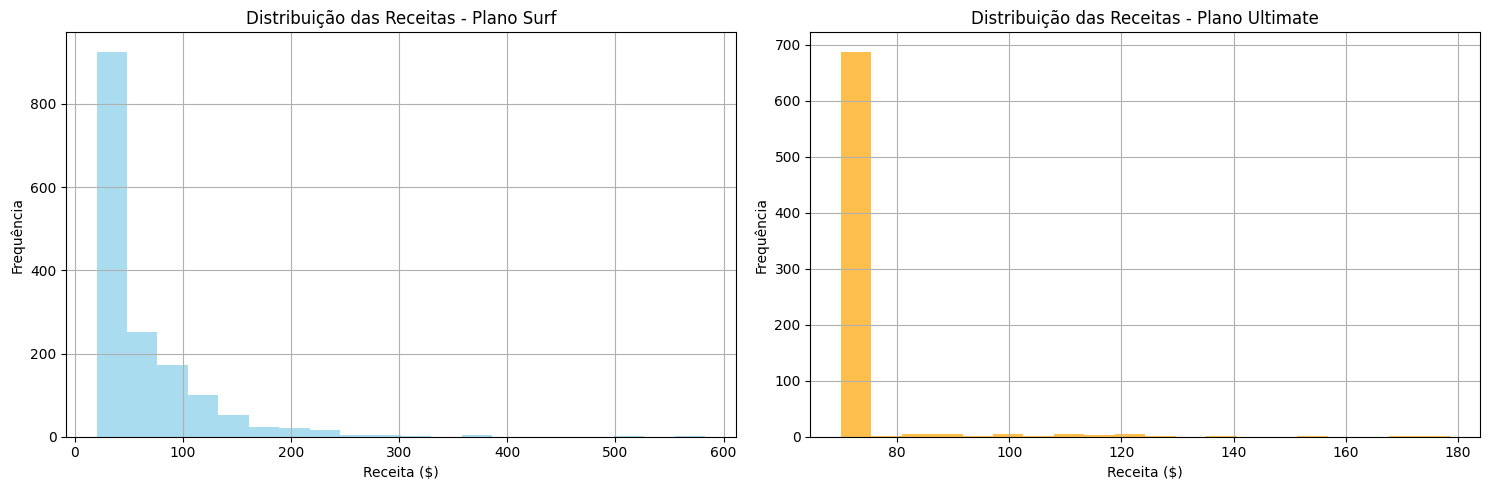

In [436]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
surf_revenue.hist(bins=20, alpha=0.7, color='skyblue')
plt.title('Distribuição das Receitas - Plano Surf')
plt.xlabel('Receita ($)')
plt.ylabel('Frequência')

plt.subplot(1, 2, 2)
ultimate_revenue.hist(bins=20, alpha=0.7, color='orange')
plt.title('Distribuição das Receitas - Plano Ultimate')
plt.xlabel('Receita ($)')
plt.ylabel('Frequência')

plt.tight_layout()
plt.show()

<Figure size 1200x600 with 0 Axes>

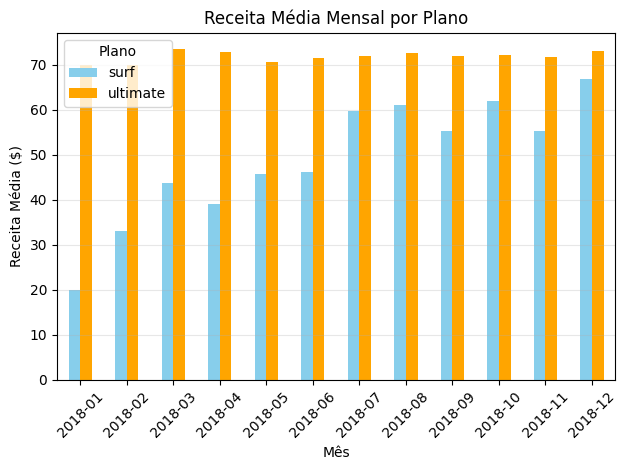

In [437]:
monthly_revenue = df_users_plans_total.groupby(['plan_name', 'month_year'])['total_revenue'].mean().reset_index()
monthly_revenue_pivot = monthly_revenue.pivot(index='month_year', columns='plan_name', values='total_revenue')

plt.figure(figsize=(12, 6))
monthly_revenue_pivot.plot(kind='bar', color=['skyblue', 'orange'])
plt.title('Receita Média Mensal por Plano')
plt.xlabel('Mês')
plt.ylabel('Receita Média ($)')
plt.xticks(rotation=45)
plt.legend(title='Plano')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

A análise das receitas revela que o faturamento de cada plano possui dinâmicas financeiras distintas. Enquanto o plano Ultimate apresenta uma receita estável e previsível, concentrada no valor da mensalidade, o plano Surf demonstra uma variabilidade significativamente superior.
Observa-se que, no plano Surf, uma parcela considerável do faturamento é proveniente das tarifas por serviços excedentes, visto que a receita média por usuário cresce de forma progressiva ao longo do ano. Portanto, conclui-se que o plano Ultimate lucra pela taxa de adesão elevada e constante, ao passo que a rentabilidade do plano Surf é impulsionada pelo consumo que ultrapassa as franquias contratadas, resultando em cobranças adicionais variadas.

## Teste hipóteses estatísticas

Testando a hipótese de que a receita média dos usuários é diferente entre os dois planos Ultimate e Surf

In [439]:
# Teste as hipóteses
surf_revenue = df_users_plans_total[df_users_plans_total['plan_name'] == 'surf']['total_revenue']
ultimate_revenue = df_users_plans_total[df_users_plans_total['plan_name'] == 'ultimate']['total_revenue']
t_stat, p_value = stats.ttest_ind(surf_revenue, ultimate_revenue) 

print(f"Estatística t: {t_stat:.4f}")
print(f"Valor p: {p_value:.4f}")

Estatística t: -7.2218
Valor p: 0.0000


Com base no teste t de Student realizado, o Valor p obtido foi inferior ao nível de significância padrão de 5% (alfa = 0,05), o que permite rejeitar a hipótese nula. Portanto, conclui-se que existe uma diferença estatisticamente significativa entre as receitas médias dos usuários dos planos Ultimate e Surf. Os dados confirmam que os planos não geram o mesmo retorno financeiro médio por cliente, ratificando a distinção entre os modelos de cobrança das duas modalidades.

Testando a hipótese de que a receita média dos usuários NY-NJ é diferente do demais usuários de outras regiôes

In [442]:
# Teste as hipóteses
ny_nj_users = df_users_plans_total[df_users_plans_total['city'].str.contains('New York-Newark-Jersey City', na=False)]
other_regions_users = df_users_plans_total[~df_users_plans_total['city'].str.contains('New York-Newark-Jersey City', na=False)]
ny_nj_revenue = ny_nj_users['total_revenue']
other_regions_revenue = other_regions_users['total_revenue']

print(f"Usuários NY-NJ: {len(ny_nj_revenue)}")
print(f"Usuários outras regiões: {len(other_regions_revenue)}")

Usuários NY-NJ: 378
Usuários outras regiões: 1925


In [443]:
t_stat, p_value = stats.ttest_ind(ny_nj_revenue, other_regions_revenue)

print(f"Estatística t: {t_stat:.4f}")
print(f"Valor p: {p_value:.4f}")

Estatística t: -2.1416
Valor p: 0.0323


O teste estatístico realizado resultou em um Valor p de aproximadamente 0,032, valor este que se encontra abaixo do nível de significância de 5% ($\alpha = 0,05$). Diante desse resultado, rejeita-se a hipótese nula, evidenciando que existe uma diferença estatisticamente significativa entre a receita média dos usuários da região de NY-NJ e a dos usuários das demais regiões. Conclui-se, portanto, que a localização geográfica dos clientes exerce influência sobre o faturamento médio gerado.

## Conclusão geral

A presente análise permitiu compreender o perfil de consumo e a dinâmica financeira dos usuários da empresa de telecomunicações. As etapas de processamento e os resultados obtidos fundamentam as seguintes conclusões:

Padronização e Tratamento de Dados: A limpeza inicial, que incluiu o arredondamento de minutos e a conversão de tráfego de internet para Gigabytes, foi essencial para alinhar os dados brutos às regras de cobrança dos planos, garantindo a precisão dos cálculos de receita.

Comportamento de Consumo: Constatou-se que não há diferença significativa no volume de chamadas entre os planos. Contudo, no tráfego de internet, os usuários do plano Surf frequentemente excedem suas franquias, demonstrando uma necessidade de dados que ultrapassa o pacote básico contratado.

Dinâmica de Receita: Identificou-se que o plano Ultimate gera uma receita estável baseada na taxa de adesão, enquanto o plano Surf apresenta alta variabilidade e maior lucratividade através de cobranças por serviços excedentes, especialmente no final do período anual.

Validação Estatística: Os testes de hipóteses confirmaram, com rigor estatístico, que as receitas médias diferem significativamente tanto entre os planos quanto entre as regiões geográficas (NY-NJ versus demais regiões), validando as suposições levantadas durante a análise exploratória.

Em suma, os dados sugerem que, embora as necessidades de comunicação sejam similares entre os perfis, a estrutura tarifária de cada plano dita resultados financeiros distintos para a operadora.